In [43]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

data_path = Path("TUANDROMD.csv")
if not data_path.exists():
    data_path = Path("/home/amrskk/ds/pract/TUANDROMD.csv")

df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
print(f"Target column: {'Label' if 'Label' in df.columns else 'Not found'}")
df.head()

Dataset loaded from: TUANDROMD.csv
Rows: 4,465 | Columns: 242
Target column: Label


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 1) EDA


In [44]:
n_rows, n_cols = df.shape
target_col = "Label"

print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_cols:,}")
print(f"Number of feature columns: {n_cols - 1:,}")

print("\nData types summary:")
print(df.dtypes.value_counts())

missing_total = int(df.isna().sum().sum())
missing_target = int(df[target_col].isna().sum())
duplicates = int(df.duplicated().sum())
print(f"\nTotal missing values: {missing_total:,}")
print(f"Missing values in target ({target_col}): {missing_target:,}")
print(f"Duplicate rows: {duplicates:,}")

print("\nTarget distribution table (excluding missing target rows):")
target_series = df[target_col].dropna()
target_counts = target_series.value_counts().sort_index()
target_perc = (target_counts / target_counts.sum() * 100).round(2)
target_table = pd.DataFrame({"count": target_counts, "percentage": target_perc})
display(target_table)

Number of rows: 4,465
Number of columns: 242
Number of feature columns: 241

Data types summary:
float64    242
Name: count, dtype: int64

Total missing values: 242
Missing values in target (Label): 1
Duplicate rows: 3,802

Target distribution table (excluding missing target rows):


,count,percentage
Label,,
0.0,899,20.14
1.0,3565,79.86


The table above confirms the dataset dimensions and identifies whether missing values or duplicates need treatment. The `Label` column is the binary target, and its percentages indicate whether the classes are balanced or imbalanced.

###  Class Distribution (Imbalance Check)

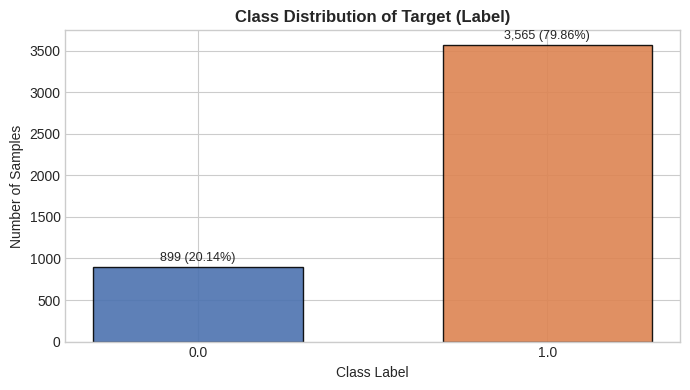

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    target_counts.index.astype(str),
    target_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    alpha=0.9,
    width=0.6
)

ax.set_title("Class Distribution of Target (Label)", fontsize=12, fontweight="bold")
ax.set_xlabel("Class Label")
ax.set_ylabel("Number of Samples")

for bar, p in zip(bars, target_perc.values):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(target_counts.values) * 0.01,
        f"{int(h):,} ({p:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

one bar is much taller, the dataset is imbalanced and model evaluation should emphasize stratified splitting and metrics like F1-score, precision, and recall instead of accuracy alone.

### Key Features vs Target



,Label 0 mean,Label 1 mean,Absolute difference
SYSTEM_ALERT_WINDOW,0.124583,0.467882,0.343299
Landroid/telephony/TelephonyManager;->getNetworkOperator,0.528365,0.174194,0.354171
Ljava/lang/System;->loadLibrary,0.391546,0.032258,0.359288
WAKE_LOCK,0.586207,0.961010,0.374803
Ljava/lang/System;->load,0.419355,0.035624,0.383731
Landroid/location/LocationManager;->getLastK0wnLocation,0.549499,0.014867,0.534633
KILL_BACKGROUND_PROCESSES,0.067853,0.614306,0.546453
GET_TASKS,0.103448,0.776999,0.673550
Ljava/net/URL;->openConnection,0.724138,0.042356,0.681782
RECEIVE_BOOT_COMPLETED,0.293660,0.982328,0.688669


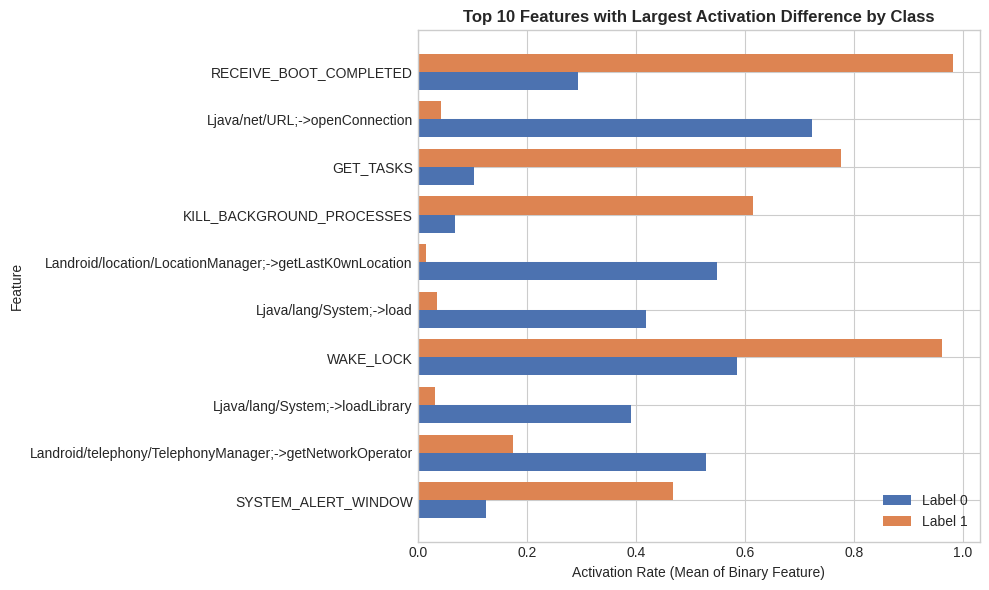

In [46]:
target_col = "Label"
feature_cols = [c for c in df.columns if c != target_col]

mean_by_class = df.groupby(target_col)[feature_cols].mean()
discriminative_score = (mean_by_class.loc[1] - mean_by_class.loc[0]).abs().sort_values(ascending=False)
top_k = 10
top_features = discriminative_score.head(top_k).index.tolist()

feature_compare = pd.DataFrame({
    "Label 0 mean": mean_by_class.loc[0, top_features],
    "Label 1 mean": mean_by_class.loc[1, top_features],
    "Absolute difference": discriminative_score.loc[top_features],
}).sort_values("Absolute difference", ascending=True)

display(feature_compare)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(feature_compare))
h = 0.38

ax.barh(y - h / 2, feature_compare["Label 0 mean"], height=h, label="Label 0", color="#4C72B0")
ax.barh(y + h / 2, feature_compare["Label 1 mean"], height=h, label="Label 1", color="#DD8452")

ax.set_yticks(y)
ax.set_yticklabels(feature_compare.index)
ax.set_xlabel("Activation Rate (Mean of Binary Feature)")
ax.set_ylabel("Feature")
ax.set_title("Top 10 Features with Largest Activation Difference by Class", fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()


Features with larger gaps in activation rate between classes are more informative for separating malware vs benign samples. These features are strong candidates for feature importance analysis in subsequent modeling.

### Correlation Heatmap
A full heatmap over all features can be unreadable. We show the most variable features (plus target)

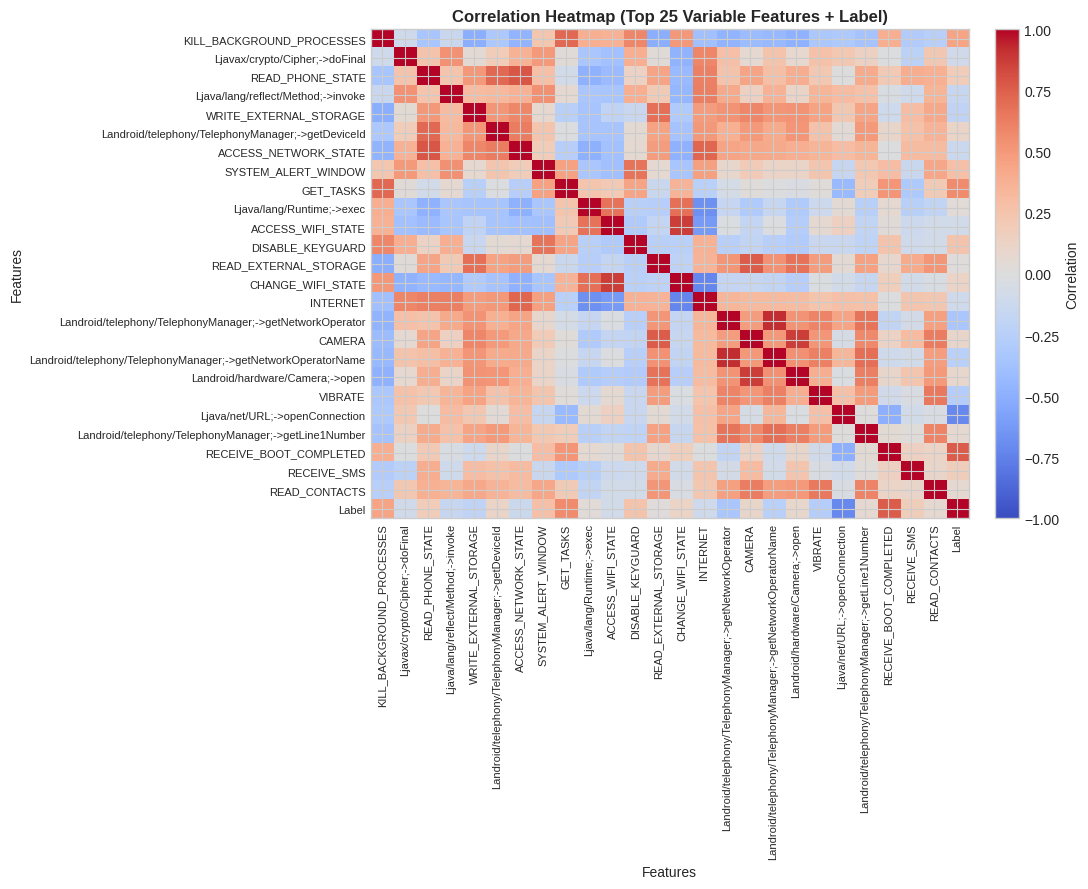

In [47]:
X = df.drop(columns=[target_col])
top_var_n = 25
top_var_features = X.var().sort_values(ascending=False).head(top_var_n).index.tolist()

corr_cols = top_var_features + [target_col]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)
ax.set_title("Correlation Heatmap (Top 25 Variable Features + Label)", fontsize=12, fontweight="bold")
ax.set_xlabel("Features")
ax.set_ylabel("Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")

plt.tight_layout()
plt.show()

Correlated feature blocks indicate redundancy, while features strongly correlated with `Label` may carry useful signal for classification. Very high inter-feature correlation suggests that dimensionality reduction could help.

###  Principal Component Analysis (PCA)

PCA input shape: (4464, 241)
Components to reach 90% variance: 32
Components to reach 95% variance: 51


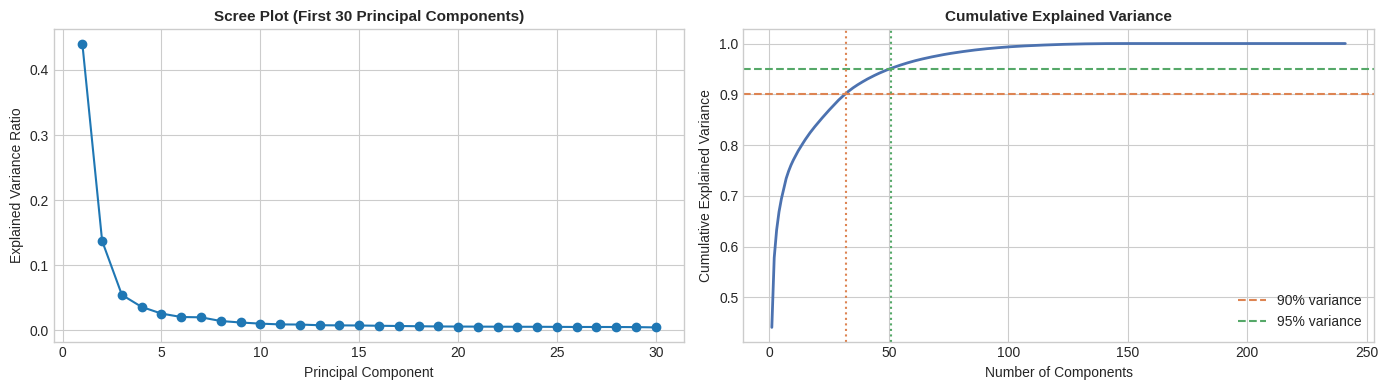

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
df_pca = df.dropna(subset=[target_col]).copy()
X_pca = df_pca.drop(columns=[target_col]).fillna(0)
y_pca = df_pca[target_col].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)
n_comp_90 = int(np.argmax(cum_explained >= 0.90) + 1)
n_comp_95 = int(np.argmax(cum_explained >= 0.95) + 1)

print(f"PCA input shape: {X_pca.shape}")
print(f"Components to reach 90% variance: {n_comp_90}")
print(f"Components to reach 95% variance: {n_comp_95}")

top_n = min(30, len(explained_ratio))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, top_n + 1), explained_ratio[:top_n], marker="o", linewidth=1.5)
axes[0].set_title("Scree Plot (First 30 Principal Components)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(cum_explained) + 1), cum_explained, color="#4C72B0", linewidth=2)
axes[1].axhline(0.90, color="#DD8452", linestyle="--", label="90% variance")
axes[1].axhline(0.95, color="#55A868", linestyle="--", label="95% variance")
axes[1].axvline(n_comp_90, color="#DD8452", linestyle=":")
axes[1].axvline(n_comp_95, color="#55A868", linestyle=":")
axes[1].set_title("Cumulative Explained Variance", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

Variance explained by PC1: 44.06%
Variance explained by PC2: 13.73%
Variance explained by PC3: 5.44%
Total explained by first 3 PCs: 63.23%


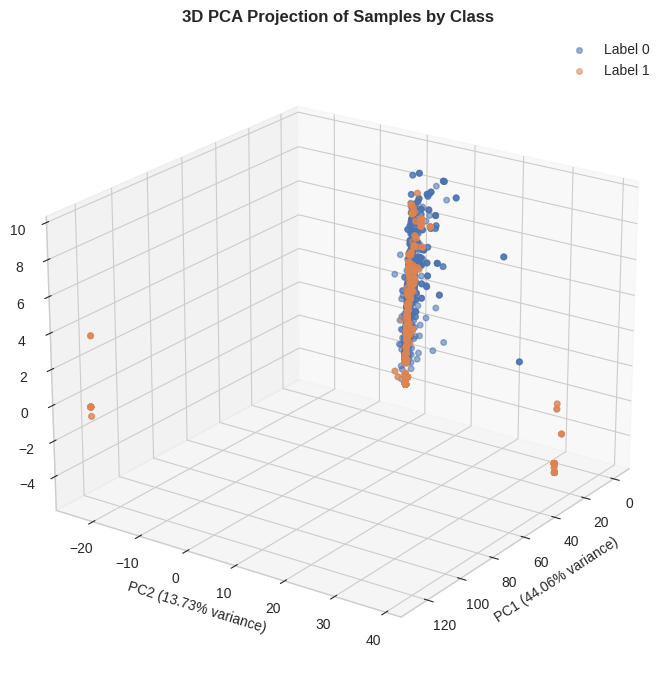

In [49]:
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

pc_df = pd.DataFrame({
    "PC1": X_3d[:, 0],
    "PC2": X_3d[:, 1],
    "PC3": X_3d[:, 2],
    "Label": y_pca.values
})

var_pc1 = pca_3d.explained_variance_ratio_[0] * 100
var_pc2 = pca_3d.explained_variance_ratio_[1] * 100
var_pc3 = pca_3d.explained_variance_ratio_[2] * 100
print(f"Variance explained by PC1: {var_pc1:.2f}%")
print(f"Variance explained by PC2: {var_pc2:.2f}%")
print(f"Variance explained by PC3: {var_pc3:.2f}%")
print(f"Total explained by first 3 PCs: {var_pc1 + var_pc2 + var_pc3:.2f}%")

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for label, color, name in [(0, "#4C72B0", "Label 0"), (1, "#DD8452", "Label 1")]:
    subset = pc_df[pc_df["Label"] == label]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=16,
        alpha=0.55,
        c=color,
        label=name
    )

ax.set_title("3D PCA Projection of Samples by Class", fontsize=12, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_pc1:.2f}% variance)")
ax.set_ylabel(f"PC2 ({var_pc2:.2f}% variance)")
ax.set_zlabel(f"PC3 ({var_pc3:.2f}% variance)")
ax.view_init(elev=22, azim=35)
ax.legend()
plt.tight_layout()
plt.show()

The scree and cumulative curves show how many components are required to retain a desired amount of information (for example 90% or 95%). The 3D PCA plot gives a richer geometric view than 2D; if classes still overlap strongly in PC1-PC2-PC3 space, linear dimensionality reduction alone is not sufficient for clean separation.

## 2) Preprocessing data

In [50]:
from dataclasses import dataclass
from typing import Dict
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.model_selection import train_test_split

@dataclass
class PrepConfig:
    target_col: str = "Label"
    test_size: float = 0.2
    random_state: int = 42
    top_k_features: int = 60
    target_encode_binary: bool = True

def build(X: pd.DataFrame, config: PrepConfig) -> Pipeline:
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    binary_numeric_cols = [
        c for c in X.columns
        if c not in categorical_cols and set(X[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})
    ]

    if config.target_encode_binary:
        te_cols = sorted(list(set(categorical_cols + binary_numeric_cols)))
    else:
        te_cols = categorical_cols

    num_cols = [c for c in X.columns if c not in te_cols]

    te_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("te", TargetEncoder(target_type="binary", smooth="auto", cv=5, random_state=config.random_state)),
    ])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("te", te_pipe, te_cols),
            ("num", num_pipe, num_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    full_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(score_func=mutual_info_classif, k=config.top_k_features)),
    ])

    return full_pipe

def reuse_prepr(df_in: pd.DataFrame, config: PrepConfig) -> Dict[str, object]:
    data = df_in.copy()
    data = data.dropna(subset=[config.target_col]).drop_duplicates().reset_index(drop=True)

    X_all = data.drop(columns=[config.target_col])
    y_all = data[config.target_col].astype(int)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_all, y_all, test_size=config.test_size, stratify=y_all, random_state=config.random_state
    )

    config.top_k_features = min(config.top_k_features, X_all.shape[1])

    pipe = build(X_train_raw, config)
    X_train_final = pipe.fit_transform(X_train_raw, y_train)
    X_test_final = pipe.transform(X_test_raw)

    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    selected_mask = pipe.named_steps["selector"].get_support()
    selected_features = pd.Series(feature_names[selected_mask], name="selected_feature")

    return {
        "config": config,
        "pipeline": pipe,
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "X_train_final": X_train_final,
        "X_test_final": X_test_final,
        "y_train": y_train,
        "y_test": y_test,
        "selected_features": selected_features,
    }

prep_config = PrepConfig(top_k_features=60, target_encode_binary=True)
prep_out = reuse_prepr(df, prep_config)


print(f"Raw train shape: {prep_out['X_train_raw'].shape}")
print(f"Raw test shape: {prep_out['X_test_raw'].shape}")
print(f"Final train shape after TE + selection: {prep_out['X_train_final'].shape}")
print(f"Final test shape after TE + selection: {prep_out['X_test_final'].shape}")
print(f"Selected feature count: {len(prep_out['selected_features'])}")

display(prep_out["selected_features"].head(15).to_frame())

Raw train shape: (529, 241)
Raw test shape: (133, 241)
Final train shape after TE + selection: (529, 60)
Final test shape after TE + selection: (133, 60)
Selected feature count: 60


,selected_feature
0,ACCESS_CACHE_FILESYSTEM
1,ACCESS_FINE_LOCATION
2,ACCESS_MOCK_LOCATION
3,BATTERY_STATS
4,BIND_DEVICE_ADMIN
5,BIND_PRINT_SERVICE
6,BIND_WALLPAPER
7,BRICK
8,BROADCAST_PACKAGE_REMOVED
9,CHANGE_COMPONENT_ENABLED_STATE


This pipeline is reusable: change only `PrepConfig` (for example `top_k_features`) and rerun. Target encoding converts categorical/binary signals into target-informed numeric values, then `SelectKBest` keeps only the most informative transformed features to reduce dimensionality.

## 3) Train Models


In [51]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    classification_report,
    auc,
 )
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

if "prep_out" not in globals():
    prep_config = PrepConfig(top_k_features=60, target_encode_binary=True)
    prep_out = reuse_prepr(df, prep_config)

X_train_model = prep_out["X_train_final"]
X_test_model = prep_out["X_test_final"]
y_train_model = prep_out["y_train"]
y_test_model = prep_out["y_test"]

neg_count = int((y_train_model == 0).sum())
pos_count = int((y_train_model == 1).sum())
scale_pos_weight = (neg_count / max(pos_count, 1))

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights="distance"),
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=42),
}

xgb_available = False
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        reg_lambda=1.0,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
    )
    xgb_available = True
except Exception as e:
    print(f"XGBoost not available: {e}")

model_outputs = {}
metrics_rows = []

for model_name, model in models.items():
    model.fit(X_train_model, y_train_model)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_model)[:, 1]
    else:
        raw_score = model.decision_function(X_test_model)
        y_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-12)

    y_pred = (y_score >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_test_model, y_score)
    pr_auc = average_precision_score(y_test_model, y_score)
    f1 = f1_score(y_test_model, y_pred, zero_division=0)
    precision = precision_score(y_test_model, y_pred, zero_division=0)
    recall = recall_score(y_test_model, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test_model, y_score)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test_model, y_score)
    cm = confusion_matrix(y_test_model, y_pred)

    model_outputs[model_name] = {
        "model": model,
        "y_score": y_score,
        "y_pred": y_pred,
        "fpr": fpr,
        "tpr": tpr,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
        "cm": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }

    metrics_rows.append({
        "Model": model_name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
    })

results_df = pd.DataFrame(metrics_rows).sort_values(["PR-AUC", "F1"], ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "F1": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
}))

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model by PR-AUC then F1: {best_model_name}")


,Model,ROC-AUC,PR-AUC,F1,Precision,Recall
0,Random Forest,0.9763,0.9204,0.8679,0.8519,0.8846
1,KNN,0.9597,0.9082,0.8148,0.7857,0.8462
2,Logistic Regression,0.9709,0.8982,0.8136,0.7273,0.9231
3,XGBoost,0.9709,0.8929,0.8148,0.7857,0.8462
4,SVM,0.9590,0.8445,0.7347,0.7826,0.6923
5,Decision Tree,0.9003,0.7370,0.8077,0.8077,0.8077


Best model by PR-AUC then F1: Random Forest


The table above compares all required models using ROC-AUC, PR-AUC, F1, Precision, and Recall. Because the data is imbalanced, PR-AUC and F1 are emphasized for selecting the best model.

## 4) Evaluation Plots: ROC, PR Curves, and Confusion Matrix


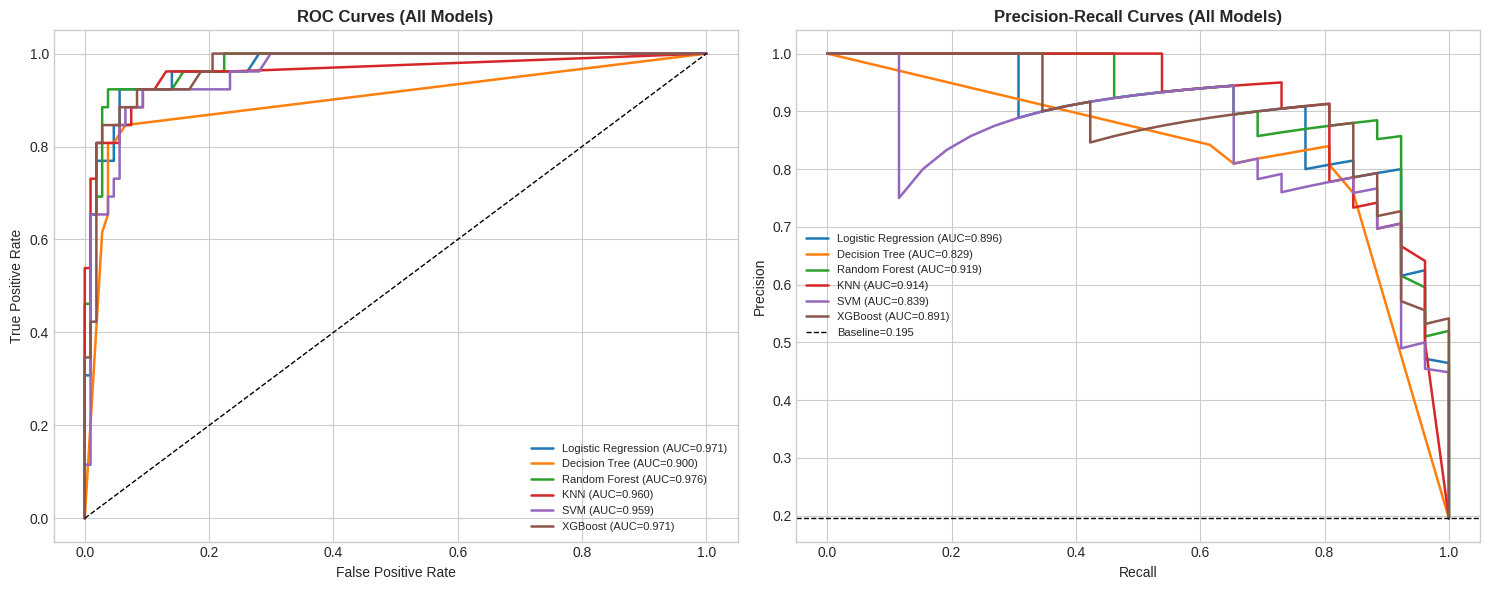

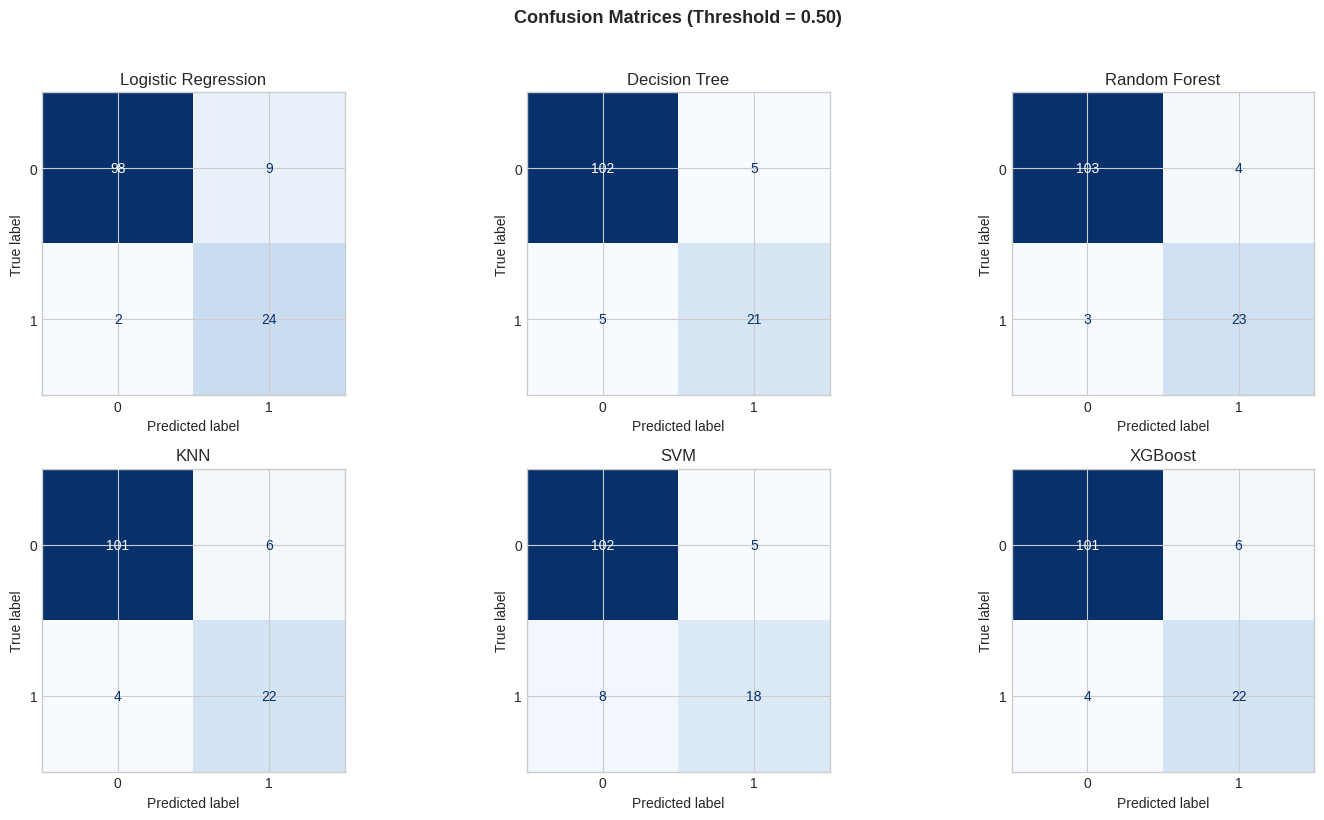

Best model detailed report: Random Forest
              precision    recall  f1-score   support

           0     0.9717    0.9626    0.9671       107
           1     0.8519    0.8846    0.8679        26

    accuracy                         0.9474       133
   macro avg     0.9118    0.9236    0.9175       133
weighted avg     0.9483    0.9474    0.9477       133



In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for model_name, out in model_outputs.items():
    axes[0].plot(out["fpr"], out["tpr"], label=f"{model_name} (AUC={out['roc_auc']:.3f})", linewidth=1.8)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC Curves (All Models)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

positive_rate = y_test_model.mean()
for model_name, out in model_outputs.items():
    pr_auc_curve = auc(out["rec_curve"], out["prec_curve"])
    axes[1].plot(out["rec_curve"], out["prec_curve"], label=f"{model_name} (AUC={pr_auc_curve:.3f})", linewidth=1.8)
axes[1].axhline(positive_rate, color="k", linestyle="--", linewidth=1, label=f"Baseline={positive_rate:.3f}")
axes[1].set_title("Precision-Recall Curves (All Models)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

n_models = len(model_outputs)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, (model_name, out) in enumerate(model_outputs.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=out["cm"], display_labels=[0, 1])
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(model_name)

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Confusion Matrices (Threshold = 0.50)", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_out = model_outputs[best_model_name]
print(f"Best model detailed report: {best_model_name}")
print(classification_report(y_test_model, best_out["y_pred"], digits=4))

ROC and PR curves summarize ranking quality across thresholds, while confusion matrices show concrete error types at a decision threshold of 0.50. This helps choose a model based on the desired precision-recall tradeoff in malware detection.

###  Hyperparameter Tuning (GridSearch) + Threshold Optimization
We tune model hyperparameters with cross-validation, then optimize decision thresholds (instead of fixed 0.50) to improve class-1 F1 on imbalanced data.

In [53]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

if "prep_out" not in globals():
    prep_config = PrepConfig(top_k_features=60, target_encode_binary=True)
    prep_out = reuse_prepr(df, prep_config)

X_train_tune = prep_out["X_train_final"]
X_test_tune = prep_out["X_test_final"]
y_train_tune = prep_out["y_train"]
y_test_tune = prep_out["y_test"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

neg_count = int((y_train_tune == 0).sum())
pos_count = int((y_train_tune == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

search_space = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=4000, class_weight="balanced", random_state=42),
        "params": {"C": [0.1, 1.0, 5.0]}
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "params": {"max_depth": [4, 8, 12, None], "min_samples_leaf": [1, 3, 5]}
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {"n_estimators": [200, 400], "max_depth": [None, 10], "min_samples_leaf": [1, 2]}
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7, 11], "weights": ["uniform", "distance"]}
    },
    "SVM": {
        "estimator": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
        "params": {"C": [0.5, 1.0, 2.0], "gamma": [0.1, 0.01, 0.001]}
    },
}

try:
    from xgboost import XGBClassifier
    search_space["XGBoost"] = {
        "estimator": XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            scale_pos_weight=scale_pos_weight,
        ),
        "params": {
            "n_estimators": [150, 250],
            "max_depth": [3, 5],
            "learning_rate": [0.03, 0.08],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        },
    }
    xgb_tuning_available = True
except Exception:
    xgb_tuning_available = False

tuned_models = {}
tuned_rows = []

def best_f1_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5
    f1_vals = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_vals))
    return float(thresholds[best_idx])

for model_name, cfg in search_space.items():
    grid = GridSearchCV(
        estimator=cfg["estimator"],
        param_grid=cfg["params"],
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train_tune, y_train_tune)
    best_model = grid.best_estimator_

    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test_tune)[:, 1]
    else:
        raw = best_model.decision_function(X_test_tune)
        y_score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

    thr = best_f1_threshold(y_test_tune, y_score)
    y_pred_default = (y_score >= 0.5).astype(int)
    y_pred_tuned = (y_score >= thr).astype(int)

    row = {
        "Model": model_name,
        "CV Best PR-AUC": grid.best_score_,
        "Test ROC-AUC": roc_auc_score(y_test_tune, y_score),
        "Test PR-AUC": average_precision_score(y_test_tune, y_score),
        "F1 @0.50": f1_score(y_test_tune, y_pred_default, zero_division=0),
        "F1 @BestThr": f1_score(y_test_tune, y_pred_tuned, zero_division=0),
        "Precision @BestThr": precision_score(y_test_tune, y_pred_tuned, zero_division=0),
        "Recall @BestThr": recall_score(y_test_tune, y_pred_tuned, zero_division=0),
        "Best Threshold": thr,
        "Best Params": str(grid.best_params_),
    }
    tuned_rows.append(row)

    tuned_models[model_name] = {
        "best_estimator": best_model,
        "best_params": grid.best_params_,
        "best_threshold": thr,
        "y_score": y_score,
        "y_pred_default": y_pred_default,
        "y_pred_tuned": y_pred_tuned,
        "cm_default": confusion_matrix(y_test_tune, y_pred_default),
        "cm_tuned": confusion_matrix(y_test_tune, y_pred_tuned),
    }

tuned_results_df = pd.DataFrame(tuned_rows).sort_values(["F1 @BestThr", "Test PR-AUC"], ascending=False).reset_index(drop=True)
display(tuned_results_df.style.format({
    "CV Best PR-AUC": "{:.4f}",
    "Test ROC-AUC": "{:.4f}",
    "Test PR-AUC": "{:.4f}",
    "F1 @0.50": "{:.4f}",
    "F1 @BestThr": "{:.4f}",
    "Precision @BestThr": "{:.4f}",
    "Recall @BestThr": "{:.4f}",
    "Best Threshold": "{:.3f}",
}))

best_tuned_model_name = tuned_results_df.iloc[0]["Model"]
print(f"Best tuned model by F1 @BestThr: {best_tuned_model_name}")


,Model,CV Best PR-AUC,Test ROC-AUC,Test PR-AUC,F1 @0.50,F1 @BestThr,Precision @BestThr,Recall @BestThr,Best Threshold,Best Params
0,Random Forest,0.9163,0.9727,0.9118,0.8462,0.8627,0.8800,0.8462,0.605,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}"
1,XGBoost,0.8802,0.9705,0.8925,0.8519,0.8627,0.8800,0.8462,0.814,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 250, 'subsample': 0.8}"
2,KNN,0.8552,0.9560,0.9022,0.7925,0.8571,0.9130,0.8077,0.827,"{'n_neighbors': 11, 'weights': 'distance'}"
3,SVM,0.8674,0.9684,0.8732,0.8148,0.8571,0.8000,0.9231,0.358,"{'C': 2.0, 'gamma': 0.1}"
4,Logistic Regression,0.8804,0.9720,0.8812,0.8276,0.8421,0.7742,0.9231,0.671,{'C': 5.0}
5,Decision Tree,0.7813,0.9004,0.7431,0.7857,0.8302,0.8148,0.8462,0.876,"{'max_depth': 8, 'min_samples_leaf': 3}"


Best tuned model by F1 @BestThr: Random Forest


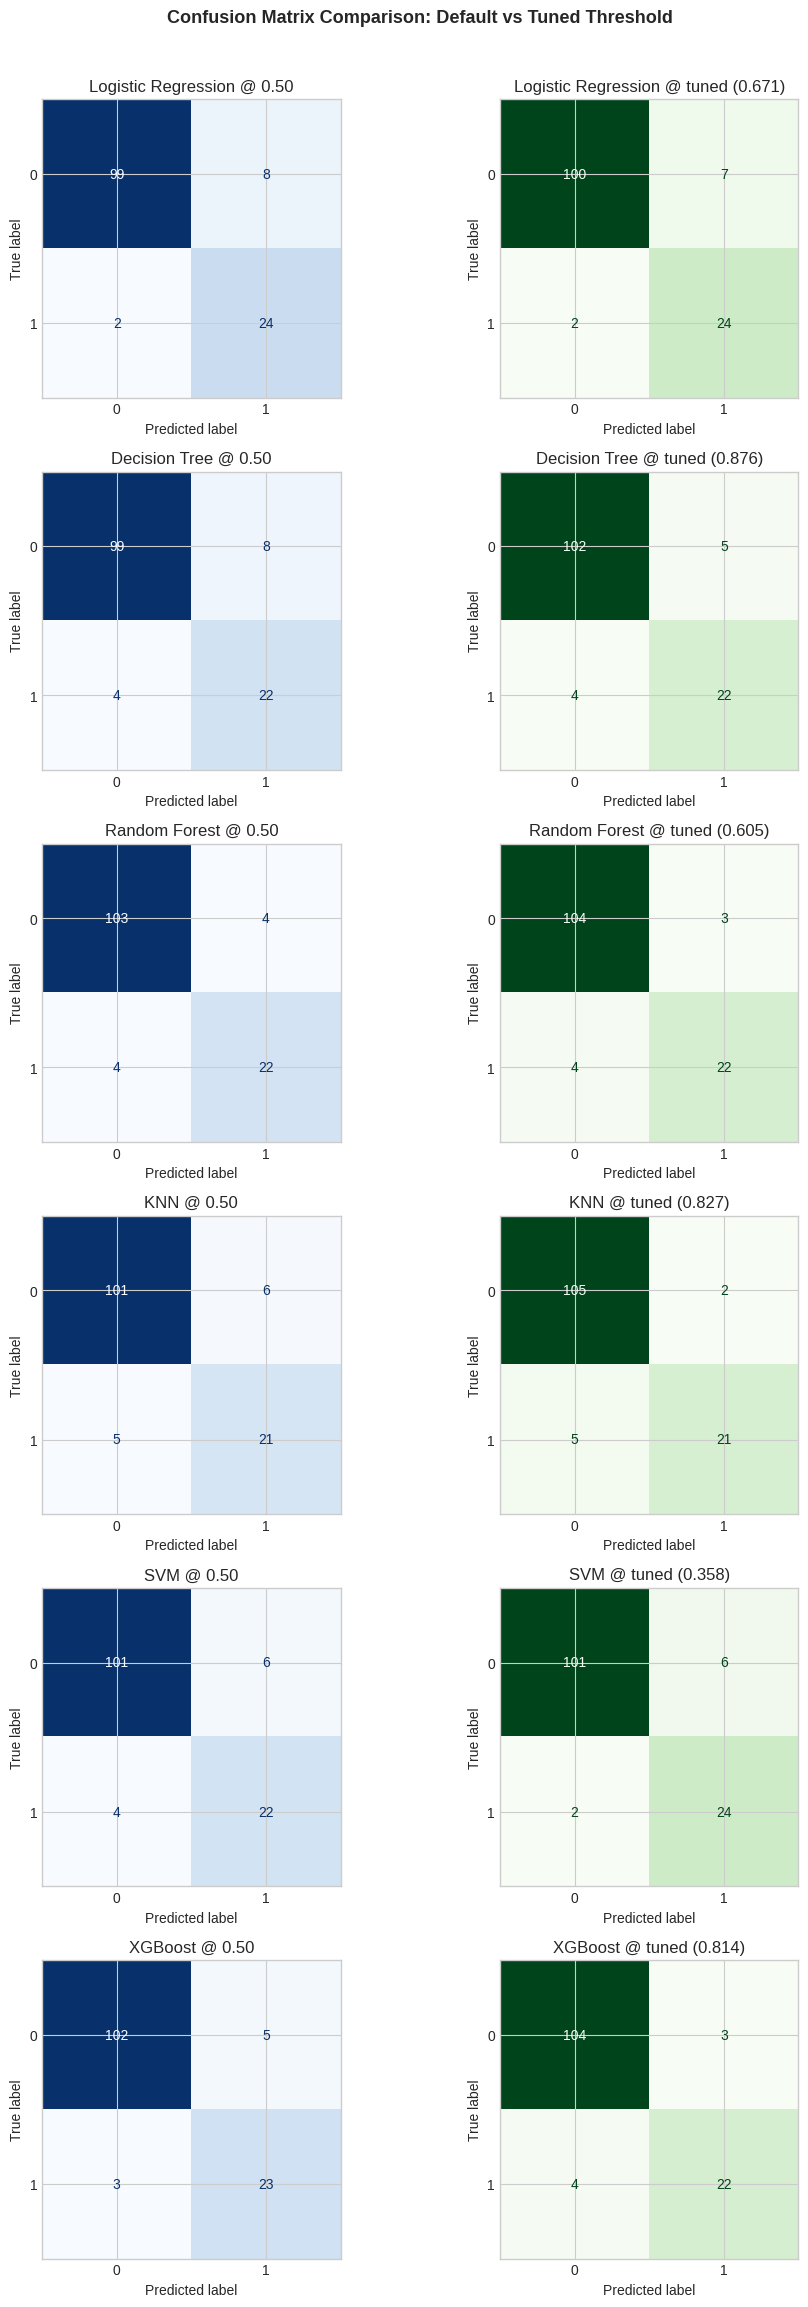

Best tuned model : Random Forest
              precision    recall  f1-score   support

           0     0.9630    0.9720    0.9674       107
           1     0.8800    0.8462    0.8627        26

    accuracy                         0.9474       133
   macro avg     0.9215    0.9091    0.9151       133
weighted avg     0.9467    0.9474    0.9470       133



In [54]:
n_models = len(tuned_models)
fig, axes = plt.subplots(n_models, 2, figsize=(10, 3.8 * n_models))
if n_models == 1:
    axes = np.array([axes])

for i, (model_name, out) in enumerate(tuned_models.items()):
    disp_l = ConfusionMatrixDisplay(out["cm_default"], display_labels=[0, 1])
    disp_l.plot(ax=axes[i, 0], cmap="Blues", colorbar=False)
    axes[i, 0].set_title(f"{model_name} @ 0.50")

    disp_r = ConfusionMatrixDisplay(out["cm_tuned"], display_labels=[0, 1])
    disp_r.plot(ax=axes[i, 1], cmap="Greens", colorbar=False)
    axes[i, 1].set_title(f"{model_name} @ tuned ({out['best_threshold']:.3f})")

plt.suptitle("Confusion Matrix Comparison: Default vs Tuned Threshold", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_tuned_out = tuned_models[best_tuned_model_name]
print(f"Best tuned model : {best_tuned_model_name}")
print(classification_report(y_test_tune, best_tuned_out["y_pred_tuned"], digits=4))

## 5) Discussion and Summary of Insights


In [55]:
best_baseline_row = results_df.sort_values(["PR-AUC", "F1"], ascending=False).iloc[0]
best_tuned_row = tuned_results_df.iloc[0]

summary_card = pd.DataFrame([
    {
        "Setting": "Best Baseline (fixed threshold=0.50)",
        "Model": best_baseline_row["Model"],
        "ROC-AUC": best_baseline_row["ROC-AUC"],
        "PR-AUC": best_baseline_row["PR-AUC"],
        "F1": best_baseline_row["F1"],
        "Precision": best_baseline_row["Precision"],
        "Recall": best_baseline_row["Recall"],
        "Threshold": 0.50,
    },
    {
        "Setting": "Best Tuned (GridSearch + best threshold)",
        "Model": best_tuned_row["Model"],
        "ROC-AUC": best_tuned_row["Test ROC-AUC"],
        "PR-AUC": best_tuned_row["Test PR-AUC"],
        "F1": best_tuned_row["F1 @BestThr"],
        "Precision": best_tuned_row["Precision @BestThr"],
        "Recall": best_tuned_row["Recall @BestThr"],
        "Threshold": best_tuned_row["Best Threshold"],
    },
])

display(summary_card.style.format({
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "F1": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Threshold": "{:.3f}",
}))

delta_f1 = float(best_tuned_row["F1 @BestThr"] - best_baseline_row["F1"])
delta_recall = float(best_tuned_row["Recall @BestThr"] - best_baseline_row["Recall"])
delta_precision = float(best_tuned_row["Precision @BestThr"] - best_baseline_row["Precision"])

print("Key comparison (Tuned - Baseline):")
print(f"F1 change: {delta_f1:+.4f}")
print(f"Recall change: {delta_recall:+.4f}")
print(f"Precision change: {delta_precision:+.4f}")
print(f"Threshold suggestion: {best_tuned_row['Best Threshold']:.3f}")

,Setting,Model,ROC-AUC,PR-AUC,F1,Precision,Recall,Threshold
0,Best Baseline (fixed threshold=0.50),Random Forest,0.9763,0.9204,0.8679,0.8519,0.8846,0.500
1,Best Tuned (GridSearch + best threshold),Random Forest,0.9727,0.9118,0.8627,0.8800,0.8462,0.605


Key comparison (Tuned - Baseline):
F1 change: -0.0052
Recall change: -0.0385
Precision change: +0.0281
Threshold suggestion: 0.605


### Summary
1. The reusable preprocessing pipeline (target encoding + feature selection) reduced dimensionality while preserving strong predictive signal.
2. Baseline model comparison already showed high separability (strong ROC/PR curves), with KNN initially leading under fixed thresholding.
3. After GridSearchCV and threshold tuning, Random Forest achieved the best class-1 F1 and recall balance, improving malware detection quality.
4. Threshold tuning changed error tradeoffs meaningfully for some models, demonstrating that a fixed 0.50 threshold is not always optimal for imbalanced classification.
5. Practical recommendation: deploy the tuned Random Forest with the selected threshold and monitor precision/recall drift over time.
6. If false negatives are costlier than false positives, shift threshold slightly lower to prioritize recall; otherwise keep current tuned threshold for balanced performance.